# Getting started

## Installation

To install the last version of `ugropy` uploaded to [PyPI](https://pypi.org/project/ugropy/) simply do:

```
pip install ugropy
```

If you are working on a google colab use:

```
%pip install ugropy
```

If you are a developer who wants to contribute to `ugropy`, you can install
it in development mode by cloning the repository and running:

```
pip install -e .
```

## Citing ugropy

If you use `ugropy` in your research, please cite the following [article](https://doi.org/10.1021/acs.iecr.5c02552):

```
@article{brandolin2025ugropy,
  title={Ugropy: An Extensible Python Package for Thermodynamic Model Functional Group Identification via Mathematical Optimization},
  author={Brandol{\'\i}n, Salvador E and Benelli, Federico E and Magario, Ivana and Scilipoti, Jos{\'e} A},
  journal={Industrial \& Engineering Chemistry Research},
  volume={64},
  number={35},
  pages={17217--17227},
  year={2025},
  publisher={ACS Publications},
  doi = {10.1021/acs.iecr.5c02552}
}
```

## About the algorithm

First, `ugropy`'s algorithm relies on three major dependency libraries:

- [RDKit](https://www.rdkit.org/): for handling chemical structures and performing substructure searches.
- [PuLP](https://github.com/coin-or/pulp): for formulating and solving the integer optimization problems.
- [PubChemPy](https://github.com/mcs07/PubChemPy): for retrieving chemical information (SMILES) from the PubChem database.

Without the capabilities of these libraries, `ugropy` would not be able to
perform its core functions effectively. `RDKit` allows for efficient
manipulation of chemical structures, while `PuLP` provides a powerful framework
for solving the optimization problems that arise in functional group
identification. `PubChemPy` enables access to SMILES strings from the
molecules' names.

`ugropy`'s algorithm is based on the concept of fragmentation, which involves
selecting a set of fragments (functional groups) that can be used to represent
the molecule from a list of structures.

The `RDKit` library is used to perform substructure searches, for example,
let's imagine that we have a very simple fragmentation model that only detects
the presence of methyl (CH3) and ethyl (CH2) fragments.

In [1]:
from rdkit import Chem


# Definition of the fragments of our model
ch3 = Chem.MolFromSmarts("[CX4H3]")
ch2 = Chem.MolFromSmarts("[CX4H2]")

In the majority of fragmentation models, we usually have to specify
which fragments are used to represent a molecule and the number of times that
fragments are present in the molecule. For example, if we want to fragment the
n-hexane molecule with our simple fragmentation model, we can simply do it with
the `RDKit` library as follows:

In [2]:
# Molecule to fragment
hexane = Chem.MolFromSmiles("CCCCCC")

In [3]:
ch3_detections = hexane.GetSubstructMatches(ch3)

ch3_detections

((0,), (5,))

In [4]:
ch2_detections = hexane.GetSubstructMatches(ch2)

ch2_detections

((1,), (2,), (3,), (4,))

`RDKit` is returning a tuple of tuples for each fragment, where each inner
tuple contains the indices of the atoms that match the fragment. The length of
the outer tuple indicates how many times the fragment is present in the
molecule. In this case, we have 2 methyl groups and 4 ethyl groups in the
n-hexane molecule. For that we can directly build a dictionary that represents
the result of the n-hexane fragmentation with our simple model:

In [5]:
solution = {
    "CH3": len(ch3_detections),
    "CH2": len(ch2_detections),
}

solution

{'CH3': 2, 'CH2': 4}

This simple molecule with this simple fragmentation model was the start of the
development of `ugropy`:

    "Well... now we just need to add all the fragments of a model like UNIFAC,
    make a direct detection with RDKit for each one and that's all... right?".

Well, no. The problem is that some fragments can overlap on the molecule's
atoms when performing a direct detection. Let's check the following example:

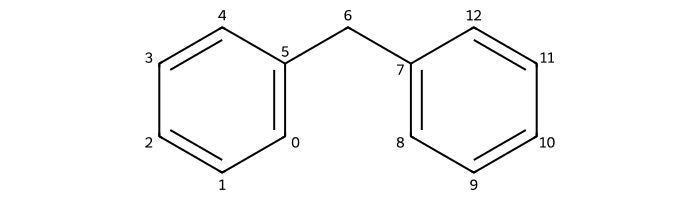

In [6]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG


mol = Chem.MolFromSmiles("c1ccccc1Cc2ccccc2")

drawer = rdMolDraw2D.MolDraw2DSVG(700, 200)
opts = drawer.drawOptions()

opts.addAtomIndices = True

drawer.DrawMolecule(mol)
drawer.FinishDrawing()

SVG(drawer.GetDrawingText())

In many fragmentation models like UNIFAC, there are fragments to differentiate
between aliphatic and aromatic carbons. Let's imagine the following
fragmentation model:

In [7]:
# Definition of the fragments of our model

# Aliphatic CH2
ch2 = Chem.MolFromSmarts("[CX4H2]")

# Aromatic CH
ach = Chem.MolFromSmarts("[cH]")

# Aromatic C without H
ac = Chem.MolFromSmarts("[cH0]")

# Aromatic C bonded with aliphatic CH2
acch2 = Chem.MolFromSmarts("[cH0]([CX4H2])")

# List of fragments of our model
fragments = [ch2, ach, ac, acch2]
fragments_names = ["CH2", "ACH", "AC", "ACCH2"]

Let's analyze the molecule with our model doing a direct detection with
`RDKit`:

In [8]:
mol = Chem.MolFromSmiles("c1ccccc1Cc2ccccc2")
occurrences = {}

print("====================================================================")
print("Atoms occupied by each fragment:")
print("--------------------------------------------------------------------")
for fragment, name in zip(fragments, fragments_names):
    detections = mol.GetSubstructMatches(fragment)
    print(f"{name}: {detections}")
    occurrences[name] = len(detections)

print("\n====================================================================")
print("Occurrence of each fragment:")
print("--------------------------------------------------------------------")
print(occurrences)

Atoms occupied by each fragment:
--------------------------------------------------------------------
CH2: ((6,),)
ACH: ((0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,))
AC: ((5,), (7,))
ACCH2: ((5, 6), (7, 6))

Occurrence of each fragment:
--------------------------------------------------------------------
{'CH2': 1, 'ACH': 10, 'AC': 2, 'ACCH2': 2}


Anyone with some experience with the UNIFAC model will know that the correct
fragmentation for this molecule is:

```
{'ACH': 10, 'AC': 1, 'ACCH2': 1}
```

You may notice that the direct detection of `ACCH2` fragment is getting two
detections. Moreover, the direct detection of `AC`, `ACCH2` and `CH2` are
overlapping in the same three atoms of the molecule.

The `ugropy`'s algorithm creates an integer (binary) optimization to solve this
decision problem of which fragments use to occupy the atoms that present
overlaps. This mathematical optimization problem is called a Set Cover Problem,
and it is solved with the `PuLP` library.

For more details about the algorithm, please refer to the [ugropy's article](https://doi.org/10.1021/acs.iecr.5c02552):


```
@article{brandolin2025ugropy,
  title={Ugropy: An Extensible Python Package for Thermodynamic Model Functional Group Identification via Mathematical Optimization},
  author={Brandol{\'\i}n, Salvador E and Benelli, Federico E and Magario, Ivana and Scilipoti, Jos{\'e} A},
  journal={Industrial \& Engineering Chemistry Research},
  volume={64},
  number={35},
  pages={17217--17227},
  year={2025},
  publisher={ACS Publications},
  doi = {10.1021/acs.iecr.5c02552}
}
```


Now, let's use `ugropy` to obtain the correct fragmentation of the molecule
with the UNIFAC model.

In [9]:
from ugropy import unifac


solution = unifac.get_groups("c1ccccc1Cc2ccccc2", "smiles")

solution.subgroups

{'ACH': 10, 'AC': 1, 'ACCH2': 1}

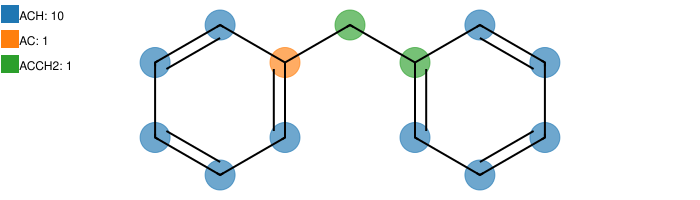

In [10]:
solution.draw(width=700)